# BF16 vs NVFP4 with NVIDIA Nemotron 3.5 Lightning

This notebook serves the same model twice on the same GPU, first in BF16 and then in NVFP4, and measures what actually changes between the two: how much memory the weights take, how much KV cache room is left over, how fast tokens come out, and whether the answers still hold up.

[NVFP4](https://developer.nvidia.com/blog/introducing-nvfp4-for-efficient-and-accurate-low-precision-inference/) is NVIDIA's 4-bit floating point format for inference. [Nemotron 3.5 Lightning](https://huggingface.co/nvidia/NVIDIA-Nemotron-3.5-Lightning-30B-A3B-BF16) ships as both a BF16 and an NVFP4 checkpoint, and at 30B total parameters with 3B active both fit on one H100, so the whole comparison runs on a single GPU.

- **BF16**: [`nvidia/NVIDIA-Nemotron-3.5-Lightning-30B-A3B-BF16`](https://huggingface.co/nvidia/NVIDIA-Nemotron-3.5-Lightning-30B-A3B-BF16)
- **NVFP4**: [`nvidia/NVIDIA-Nemotron-3.5-Lightning-30B-A3B-NVFP4`](https://huggingface.co/nvidia/NVIDIA-Nemotron-3.5-Lightning-30B-A3B-NVFP4)

**Both servers run one configuration each, with identical flags and no speculative decoding, so the checkpoint is the only thing that differs.** For the full set of tuned per-format and per-hardware configurations, see the [Nemotron 3.5 Lightning cookbooks](https://github.com/NVIDIA-NeMo/Nemotron/tree/main/usage-cookbook/Nemotron-3.5-Lightning).

Prerequisites for this notebook:
- 1x NVIDIA H100 80GB with recent drivers
- [Docker](https://docs.docker.com/engine/install/) with [NVIDIA Container Toolkit](https://docs.nvidia.com/datacenter/cloud-native/container-toolkit/install-guide.html)
- Python 3.10+
- Roughly 100GB of free disk space, since you download both checkpoints

## Table of Contents

1. **Environment setup** - Container image, client dependencies, hardware check
2. **The two configurations** - What is held fixed and what changes
3. **Measurement harness** - The code both runs share
4. **Run 1: BF16** - Serve, verify, measure
5. **Run 2: NVFP4** - Serve, verify, measure
6. **Comparison** - Both runs side by side
7. **Cleanup and next steps** - Free the GPU and go further

## Environment setup

### Launch on NVIDIA Brev

You can simplify the environment setup by using [NVIDIA Brev](https://developer.nvidia.com/brev). Click the button to launch this notebook on a Brev instance with the necessary dependencies pre-configured.

Once deployed, click on the "Open Notebook" button to get started with this guide.

**For this comparison (1x H100):**

[![Launch on Brev](https://brev-assets.s3.us-west-1.amazonaws.com/nv-lb-dark.svg)](https://brev.nvidia.com/launchable/deploy?launchableID=env-3IFOxtZMHSlYSqRlA6MuYNG9Ha1)

### Pull the vLLM Docker image

Both runs use the same [vLLM](https://docs.vllm.ai) container, which is another variable held fixed. Pull it once before starting either server:

```shell
docker pull vllm/vllm-openai:v0.27.1
```

> **Note:** This notebook uses vLLM, but can also run on SGLang and TensorRT-LLM. Detailed instructions for all three frameworks are in the [Nemotron 3.5 Lightning cookbooks](https://github.com/NVIDIA-NeMo/Nemotron/tree/main/usage-cookbook/Nemotron-3.5-Lightning).

### Install notebook client dependencies

These are for the notebook only: `openai` sends the requests that get measured and `matplotlib` draws the comparison charts. The container already carries everything the model needs in order to load and run.

In [2]:
# Bootstrap pip only if the kernel environment is missing it
import importlib.util, subprocess, sys

if importlib.util.find_spec("pip") is None:
    subprocess.run([sys.executable, "-m", "ensurepip", "--upgrade"], check=True)

%pip install -q openai==2.38.0 matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Verify GPU and disk

Confirm the GPU is visible and that there is room for both checkpoints before you start downloading them.

> **Expected output:** One row showing an H100 with roughly 80 GB of memory, then a line for the filesystem holding your Hugging Face cache. The BF16 checkpoint is about 66 GB and the NVFP4 checkpoint about 22 GB, so aim for 100 GB of headroom. If `nvidia-smi` is not found, the NVIDIA driver is not installed.

In [3]:
# Confirm the GPU is visible and check space for both checkpoints
!nvidia-smi --query-gpu=index,name,memory.total,driver_version --format=csv
!df -h ~/.cache/huggingface 2>/dev/null || df -h ~

index, name, memory.total [MiB], driver_version
0, NVIDIA H100 80GB HBM3, 81559 MiB, 580.173.02
Filesystem      Size  Used Avail Use% Mounted on
/dev/vda1       247G  123G  125G  50% /


## The two configurations

The two `vllm serve` commands below are identical except for the checkpoint path, and the same code measures both. Three of the shared choices are deliberate:

- **No speculative decoding.** Lightning's MTP, DFlash, and DSpark draft paths move token rates far more than precision does, so they stay off.
- **Prefix caching off.** The benchmark reuses one prompt, and prefix caching would serve it from cache and report a throughput number no real workload sees.
- **No format-specific tuning.** Flags such as `--moe-backend humming` are tuned per format and would help NVFP4 further. Leaving them out keeps the checkpoint as the only variable, so the NVFP4 numbers here understate a tuned deployment.

### Launch the Docker container

Open a terminal on the host and start an interactive shell inside the vLLM container. The `--network=host` flag makes the server reachable at `localhost:8000` from the notebook. You will run both `vllm serve` commands from this one shell, one after the other.

```shell
docker run --rm -it --gpus all --ipc=host --network=host \
  -v ~/.cache/huggingface:/root/.cache/huggingface \
  --entrypoint /bin/bash \
  vllm/vllm-openai:v0.27.1
```

> **Note:** Mount the Hugging Face cache directory so model weights are read from disk rather than re-downloaded on each run. Replace `~/.cache/huggingface` if your cache is in a different location.

## Measurement harness

Defined once here and called twice later, so the two runs produce directly comparable result files. Each run records weight footprint from the Hub, KV cache capacity from the server's `/metrics`, throughput and latency at three concurrency levels, and GSM8K accuracy.

### Shared settings

In [1]:
import asyncio, json, random, re, statistics, subprocess, time, urllib.request
from pathlib import Path

BASE_URL = "http://127.0.0.1:8000/v1"
METRICS_URL = "http://127.0.0.1:8000/metrics"
SERVED_MODEL_NAME = "nemotron-3.5-lightning"

BF16_REPO = "nvidia/NVIDIA-Nemotron-3.5-Lightning-30B-A3B-BF16"
NVFP4_REPO = "nvidia/NVIDIA-Nemotron-3.5-Lightning-30B-A3B-NVFP4"

# Identical for both runs
CONCURRENCIES = [1, 8, 32]   # single user, light load, heavy load
OUTPUT_TOKENS = 256          # every request emits exactly this many
ACCURACY_QUESTIONS = 100     # GSM8K test problems per run

# Results survive a kernel restart, so the comparison section works on its own
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

### Memory measurements

Weight footprint comes from the Hub because it is the one memory number that is purely a property of the format. GPU memory used will look nearly identical across both runs, since vLLM claims a fixed fraction of the card and spends whatever the weights do not need on KV cache. How that budget gets divided is the interesting part, and that is what `kv_cache_tokens` captures.

In [2]:
def weights_bytes(repo_id):
    '''Total size of a checkpoint's safetensors files, read straight from the Hub.'''
    url = f"https://huggingface.co/api/models/{repo_id}?blobs=true"
    with urllib.request.urlopen(url) as response:
        info = json.load(response)
    return sum(f["size"] for f in info["siblings"] if f["rfilename"].endswith(".safetensors"))


def kv_cache_tokens():
    '''KV cache capacity the server allocated, in tokens.

    The same figure appears in the server log as "GPU KV cache size: N tokens".
    '''
    with urllib.request.urlopen(METRICS_URL) as response:
        metrics = response.read().decode()
    line = next((l for l in metrics.splitlines() if l.startswith("vllm:cache_config_info")), "")
    blocks = re.search(r'num_gpu_blocks="(\d+)"', line)
    block_size = re.search(r'block_size="(\d+)"', line)
    return int(blocks.group(1)) * int(block_size.group(1)) if blocks and block_size else None


def gpu_memory_used_gib():
    '''Total memory in use on GPU 0, weights and caches together.'''
    query = ["nvidia-smi", "--query-gpu=memory.used", "--format=csv,noheader,nounits"]
    result = subprocess.run(query, capture_output=True, text=True, check=True)
    return int(result.stdout.strip().splitlines()[0]) / 1024


def served_model():
    '''What the server reports it is serving, including its running context length.'''
    with urllib.request.urlopen(f"{BASE_URL}/models") as response:
        return json.load(response)["data"][0]

### Throughput and latency

Every request sends the same prompt and is forced to emit exactly `OUTPUT_TOKENS` tokens with `ignore_eos`, so both formats are timed on identical work.

- **Output throughput** is total tokens divided by wall time for the level, the server-side capacity number.
- **Decode speed** is tokens per second inside one request after its first token, which is what a single user feels.
- **Time to first token** is the wait before anything comes back, driven by prefill on its own and by queueing under load.

In [3]:
from openai import AsyncOpenAI

# A fixed, repeatable prompt of roughly 1000 tokens
BENCH_PROMPT = "Summarize the following notes in one paragraph.\n\n" + (
    "Large language model inference splits into two phases with different bottlenecks. "
    "Prefill processes the whole prompt at once and is limited by arithmetic throughput. "
    "Decoding emits one token at a time and is limited by how fast weights and cache "
    "entries can be read from memory. "
) * 45


async def _timed_request(client, prompt):
    '''Stream one request, timing its first token and its full completion.'''
    start = time.perf_counter()
    ttft = None
    prompt_tokens = output_tokens = 0

    stream = await client.chat.completions.create(
        model=SERVED_MODEL_NAME,
        messages=[{"role": "user", "content": prompt}],
        temperature=1.0,
        top_p=0.95,
        max_tokens=OUTPUT_TOKENS,
        stream=True,
        stream_options={"include_usage": True},
        extra_body={"ignore_eos": True, "chat_template_kwargs": {"enable_thinking": False}},
    )
    async for chunk in stream:
        if chunk.usage:
            prompt_tokens = chunk.usage.prompt_tokens
            output_tokens = chunk.usage.completion_tokens
        if ttft is None and chunk.choices and chunk.choices[0].delta.content:
            ttft = time.perf_counter() - start

    latency = time.perf_counter() - start
    return {
        "ttft": ttft if ttft is not None else latency,
        "latency": latency,
        "prompt_tokens": prompt_tokens,
        "output_tokens": output_tokens,
    }


async def _run_level(client, concurrency, requests):
    '''Hold `concurrency` requests in flight until `requests` of them have completed.'''
    gate = asyncio.Semaphore(concurrency)

    async def one():
        async with gate:
            return await _timed_request(client, BENCH_PROMPT)

    start = time.perf_counter()
    done = await asyncio.gather(*[one() for _ in range(requests)])
    wall = time.perf_counter() - start

    decode_rates = [r["output_tokens"] / max(r["latency"] - r["ttft"], 1e-6) for r in done]
    ttfts = [r["ttft"] * 1000 for r in done]
    return {
        "concurrency": concurrency,
        "requests": requests,
        "prompt_tokens": done[0]["prompt_tokens"],
        "wall_s": wall,
        "output_throughput_tok_s": sum(r["output_tokens"] for r in done) / wall,
        "decode_tok_s_median": statistics.median(decode_rates),
        "ttft_ms_median": statistics.median(ttfts),
        "ttft_ms_max": max(ttfts),
        "latency_s_median": statistics.median(r["latency"] for r in done),
    }


async def measure_throughput():
    client = AsyncOpenAI(base_url=BASE_URL, api_key="null", timeout=1800)
    await _timed_request(client, BENCH_PROMPT)  # warmup, not recorded

    levels = []
    for concurrency in CONCURRENCIES:
        level = await _run_level(client, concurrency, max(4, 2 * concurrency))
        print(
            f"  concurrency {concurrency:>3}:"
            f" {level['output_throughput_tok_s']:7.1f} tok/s output,"
            f" {level['decode_tok_s_median']:6.1f} tok/s per request,"
            f" {level['ttft_ms_median']:7.0f} ms TTFT"
        )
        levels.append(level)

    await client.close()
    return levels

### Accuracy

Each run solves the same fixed sample of [GSM8K](https://github.com/openai/grade-school-math) grade-school word problems with reasoning on, scored on exact match: the last number in the reply has to equal the reference answer. A reply that never produces a parseable number counts as wrong, which is why the run log reports that count next to the score. Sampling is greedy rather than the model's recommended `temperature=1.0, top_p=0.95`, which removes the run-to-run randomness that would otherwise swamp a gap this small.

> **Note:** This is a smoke-level check, not a substitute for a full evaluation. At 100 questions the margin of error is a few points either way, so read it as confirmation that nothing broke. The model cards carry the full benchmark suites.

In [4]:
GSM8K_URL = (
    "https://raw.githubusercontent.com/openai/grade-school-math/"
    "master/grade_school_math/data/test.jsonl"
)
ANSWER_INSTRUCTION = (
    "Solve the problem. End your reply with the final answer as a plain number on its own line."
)
NUMBER_PATTERN = re.compile(r"-?\d+(?:\.\d+)?")


def load_questions(count):
    '''A fixed sample of GSM8K test problems, identical for every run.'''
    with urllib.request.urlopen(GSM8K_URL) as response:
        rows = [json.loads(line) for line in response.read().decode().splitlines() if line.strip()]
    random.Random(0).shuffle(rows)
    return [
        {"question": r["question"], "answer": r["answer"].split("####")[-1].strip().replace(",", "")}
        for r in rows[:count]
    ]


def final_number(text):
    '''The last number in a reply, which is where the instruction puts the answer.'''
    found = NUMBER_PATTERN.findall((text or "").replace(",", "").replace("$", ""))
    return found[-1] if found else None


def is_correct(predicted, expected):
    try:
        return abs(float(predicted) - float(expected)) < 1e-4
    except (TypeError, ValueError):
        return False


async def measure_accuracy(count=None, concurrency=16):
    questions = load_questions(count or ACCURACY_QUESTIONS)
    client = AsyncOpenAI(base_url=BASE_URL, api_key="null", timeout=1800)
    gate = asyncio.Semaphore(concurrency)

    async def solve(item):
        async with gate:
            response = await client.chat.completions.create(
                model=SERVED_MODEL_NAME,
                messages=[
                    {"role": "system", "content": ANSWER_INSTRUCTION},
                    {"role": "user", "content": item["question"]},
                ],
                temperature=0.0,
                # Thinking stays on, since this model reasons its way to a number and
                # scores far worse without it. The budget has to cover that reasoning
                # plus the answer after it, or the reply ends before the answer arrives.
                max_tokens=16384,
            )
            choice = response.choices[0]
            return final_number(choice.message.content), item["answer"], choice.finish_reason

    graded = await asyncio.gather(*[solve(item) for item in questions])
    await client.close()

    total = len(graded)
    correct = sum(1 for predicted, expected, _ in graded if is_correct(predicted, expected))
    accuracy = correct / total
    return {
        "questions": total,
        "correct": correct,
        "accuracy": accuracy,
        # Standard error on a proportion, so a gap can be read against its own noise
        "stderr": (accuracy * (1 - accuracy) / total) ** 0.5,
        "no_answer": sum(1 for predicted, _, _ in graded if predicted is None),
        # Hit the token ceiling mid-reasoning. These score as wrong, so a non-zero
        # count here means the accuracy number is pessimistic, not that the model erred
        "truncated": sum(1 for _, _, reason in graded if reason == "length"),
    }

### Putting a run together

`run_measurements` collects all four measurements plus one greedy sample answer, then writes them to `results/<label>.json`.

In [5]:
SAMPLE_PROMPT = (
    "A freight train leaves a station at 40 km/h. Two hours later an express train leaves the "
    "same station on the same track at 60 km/h. How far from the station does the express "
    "train catch up? Explain your reasoning."
)


async def sample_answer():
    '''One greedy answer, kept for a qualitative side-by-side later.'''
    client = AsyncOpenAI(base_url=BASE_URL, api_key="null", timeout=1800)
    response = await client.chat.completions.create(
        model=SERVED_MODEL_NAME,
        messages=[{"role": "user", "content": SAMPLE_PROMPT}],
        temperature=0.0,
        max_tokens=2048,
    )
    await client.close()
    message = response.choices[0].message
    return {"reasoning": message.reasoning, "content": message.content}


async def run_measurements(label, repo_id):
    '''Measure the currently running server and save the results under `label`.'''
    model = served_model()
    print(f"Measuring {label}, server is running {model.get('root', model['id'])}")

    kv_tokens = kv_cache_tokens()
    record = {
        "label": label,
        "checkpoint": repo_id,
        "weights_bytes": weights_bytes(repo_id),
        "kv_cache_tokens": kv_tokens,
        "gpu_memory_used_gib": gpu_memory_used_gib(),
        "max_model_len": model.get("max_model_len"),
    }
    print(f"  weights:  {record['weights_bytes'] / 2**30:.1f} GiB on disk")
    print(f"  KV cache: {kv_tokens:,} tokens" if kv_tokens else
          "  KV cache: not reported, read 'GPU KV cache size' from the server log")

    record["throughput"] = await measure_throughput()

    print(f"  scoring {ACCURACY_QUESTIONS} GSM8K problems, this takes a few minutes")
    record["accuracy"] = await measure_accuracy()
    print(f"  accuracy: {record['accuracy']['accuracy']:.1%}"
          f" ({record['accuracy']['no_answer']} replies with no parseable answer,"
          f" {record['accuracy']['truncated']} cut off by the token limit)")

    record["sample"] = await sample_answer()

    path = RESULTS_DIR / f"{label}.json"
    path.write_text(json.dumps(record, indent=2))
    return record

## Run 1: BF16

Start with the reference format. Run the command below inside the Docker container terminal.

> **Note:** The first launch takes a while, and the progress readout can sit at `0%` for several minutes, first while 66 GB of weights download and load, then while CUDA kernels compile. That is expected rather than a hang.

> **Note:** BF16 weights take roughly 61 GiB of an 80 GB H100, which is why 262144 is the largest context that fits. If the server fails to allocate a KV cache on your card, lower `--max-model-len` to `131072` here and in the NVFP4 command so the two runs still match.

```shell
vllm serve nvidia/NVIDIA-Nemotron-3.5-Lightning-30B-A3B-BF16 \
  --served-model-name nemotron-3.5-lightning \
  --max-model-len 262144 \
  --max-num-seqs 128 \
  --gpu-memory-utilization 0.9 \
  --no-enable-prefix-caching \
  --async-scheduling \
  --mamba-backend flashinfer \
  --mamba-ssm-cache-dtype float16 \
  --enable-mamba-cache-stochastic-rounding \
  --mamba-cache-philox-rounds 5 \
  --reasoning-parser nemotron_v3 \
  --host 127.0.0.1 \
  --port 8000
```

### Wait for the server to be ready

In a new terminal, poll `/v1/models`:

```shell
until curl -sf http://localhost:8000/v1/models | grep -q nemotron-3.5-lightning; do
  echo "Waiting for server..."; sleep 5
done
echo "Server is ready"
```

> **Expected output:** `Waiting for server...` until the model is up, then `Server is ready`. The server log also prints `GPU KV cache size: N tokens`, the same number the harness reads from `/metrics`.

### Measure

This takes a few minutes: a warmup request, then the three concurrency levels, then 100 GSM8K problems.

In [6]:
bf16 = await run_measurements("bf16", BF16_REPO)

Measuring bf16, server is running nvidia/NVIDIA-Nemotron-3.5-Lightning-30B-A3B-BF16
  weights:  61.3 GiB on disk
  KV cache: 1,729,136 tokens
  concurrency   1:   260.2 tok/s output,  279.0 tok/s per request,      66 ms TTFT
  concurrency   8:   892.1 tok/s output,  127.9 tok/s per request,     263 ms TTFT
  concurrency  32:  1769.6 tok/s output,   61.8 tok/s per request,     459 ms TTFT
  scoring 100 GSM8K problems, this takes a few minutes
  accuracy: 92.0% (1 replies with no parseable answer, 1 cut off by the token limit)


### Stop the BF16 server

The GPU has to be empty before NVFP4 can load. In the container terminal, stop the server with `Ctrl+C` and wait for the process to exit, then confirm the memory came back.

In [8]:
# Should report close to 0 MiB used before the next server starts
!nvidia-smi --query-gpu=memory.used,memory.total --format=csv

memory.used [MiB], memory.total [MiB]
0 MiB, 81559 MiB


## Run 2: NVFP4

Same command, same flags, one different checkpoint. Run it in the container terminal you just freed.

vLLM reads the quantization scheme from the checkpoint, so there is no flag for it. The first launch downloads about 22 GB.

```shell
vllm serve nvidia/NVIDIA-Nemotron-3.5-Lightning-30B-A3B-NVFP4 \
  --served-model-name nemotron-3.5-lightning \
  --max-model-len 262144 \
  --max-num-seqs 128 \
  --gpu-memory-utilization 0.9 \
  --no-enable-prefix-caching \
  --async-scheduling \
  --mamba-backend flashinfer \
  --mamba-ssm-cache-dtype float16 \
  --enable-mamba-cache-stochastic-rounding \
  --mamba-cache-philox-rounds 5 \
  --reasoning-parser nemotron_v3 \
  --host 127.0.0.1 \
  --port 8000
```

### Wait for the server to be ready

Same check as before, in a new terminal:

```shell
until curl -sf http://localhost:8000/v1/models | grep -q nemotron-3.5-lightning; do
  echo "Waiting for server..."; sleep 5
done
echo "Server is ready"
```

Both servers use the same served model name, so this loop passes for either one. The cell below prints which checkpoint actually loaded, so a stale server cannot get recorded twice.

In [9]:
# Confirm the NVFP4 checkpoint is the one loaded, not the previous server
print(served_model()["root"])

nvidia/NVIDIA-Nemotron-3.5-Lightning-30B-A3B-NVFP4


### Measure

The same harness, unchanged, against the new server.

In [10]:
nvfp4 = await run_measurements("nvfp4", NVFP4_REPO)

Measuring nvfp4, server is running nvidia/NVIDIA-Nemotron-3.5-Lightning-30B-A3B-NVFP4
  weights:  20.1 GiB on disk
  KV cache: 17,796,464 tokens
  concurrency   1:   334.5 tok/s output,  372.4 tok/s per request,      78 ms TTFT
  concurrency   8:  1290.3 tok/s output,  219.3 tok/s per request,     411 ms TTFT
  concurrency  32:  2286.1 tok/s output,   97.6 tok/s per request,     931 ms TTFT
  scoring 100 GSM8K problems, this takes a few minutes
  accuracy: 91.0% (1 replies with no parseable answer, 1 cut off by the token limit)


### Stop the NVFP4 server

Nothing below needs a GPU. Stop the server with `Ctrl+C` in the container terminal and exit the container. The comparison section reads only the saved result files.

## Comparison

Both runs are on disk now, so this section works from a clean kernel with no server running. If you took a break, restart the kernel and start from the cell below.

In [11]:
import json
from pathlib import Path

RESULTS_DIR = Path("results")
bf16 = json.loads((RESULTS_DIR / "bf16.json").read_text())
nvfp4 = json.loads((RESULTS_DIR / "nvfp4.json").read_text())

for record in (bf16, nvfp4):
    context = f"{record['max_model_len']:,}" if record["max_model_len"] else "unknown"
    print(f"{record['label']:<6} served {record['checkpoint']}, context {context}")

bf16   served nvidia/NVIDIA-Nemotron-3.5-Lightning-30B-A3B-BF16, context 262,144
nvfp4  served nvidia/NVIDIA-Nemotron-3.5-Lightning-30B-A3B-NVFP4, context 262,144


### Summary table

The `Change` column reads NVFP4 against BF16. Rates and capacities are shown as ratios, and accuracy as a difference in percentage points, since a ratio hides how small the gap is next to the margin of error.

> **Note:** The KV cache row combines two effects. Most of it is the memory the smaller weights freed up, and a factor of two comes from the KV cache dtype: the NVFP4 checkpoint declares an FP8 KV cache scheme that vLLM picks up on its own, while BF16 keeps a 16-bit cache. Neither serve command sets `--kv-cache-dtype`.

In [12]:
from IPython.display import Markdown, display


def level(record, concurrency):
    return next(l for l in record["throughput"] if l["concurrency"] == concurrency)


def show_pair(left, right):
    '''Format both sides of a row the same way, so the column reads consistently.'''
    if left is None or right is None:
        return "not reported", "not reported"
    fmt = ",.0f" if max(left, right) >= 1000 else ".1f"
    return f"{left:{fmt}}", f"{right:{fmt}}"


def change(left, right, better):
    '''Size and direction of the NVFP4 change, and whether that direction helps.'''
    if not left or not right:
        return "n/a"
    if better == "points":
        return f"{right - left:+.1f} points"
    ratio = right / left
    direction = "higher" if ratio >= 1 else "lower"
    magnitude = ratio if ratio >= 1 else 1 / ratio
    helps = (direction == "higher") == (better == "higher")
    return f"{magnitude:.2f}x {direction} ({'better' if helps else 'worse'})"


rows = [
    ("Weights on disk (GiB)", bf16["weights_bytes"] / 2**30, nvfp4["weights_bytes"] / 2**30, "lower"),
    ("KV cache capacity (tokens)", bf16["kv_cache_tokens"], nvfp4["kv_cache_tokens"], "higher"),
    ("GSM8K accuracy (%)", bf16["accuracy"]["accuracy"] * 100, nvfp4["accuracy"]["accuracy"] * 100, "points"),
]
for concurrency in [l["concurrency"] for l in bf16["throughput"]]:
    slow, fast = level(bf16, concurrency), level(nvfp4, concurrency)
    rows += [
        (f"Output throughput at c={concurrency} (tok/s)",
         slow["output_throughput_tok_s"], fast["output_throughput_tok_s"], "higher"),
        (f"Decode speed at c={concurrency} (tok/s per request)",
         slow["decode_tok_s_median"], fast["decode_tok_s_median"], "higher"),
        (f"Median TTFT at c={concurrency} (ms)",
         slow["ttft_ms_median"], fast["ttft_ms_median"], "lower"),
    ]

table = ["| Metric | BF16 | NVFP4 | Change |", "|---|---|---|---|"]
for name, left, right, better in rows:
    left_text, right_text = show_pair(left, right)
    table.append(f"| {name} | {left_text} | {right_text} | {change(left, right, better)} |")

display(Markdown("\n".join(table)))

print(f"Accuracy margin of error: BF16 +/-{bf16['accuracy']['stderr'] * 100:.1f} points,"
      f" NVFP4 +/-{nvfp4['accuracy']['stderr'] * 100:.1f} points"
      f" on {bf16['accuracy']['questions']} questions each")
print(f"GPU memory in use while serving: BF16 {bf16['gpu_memory_used_gib']:.1f} GiB,"
      f" NVFP4 {nvfp4['gpu_memory_used_gib']:.1f} GiB")

| Metric | BF16 | NVFP4 | Change |
|---|---|---|---|
| Weights on disk (GiB) | 61.3 | 20.1 | 3.05x lower (better) |
| KV cache capacity (tokens) | 1,729,136 | 17,796,464 | 10.29x higher (better) |
| GSM8K accuracy (%) | 92.0 | 91.0 | -1.0 points |
| Output throughput at c=1 (tok/s) | 260.2 | 334.5 | 1.29x higher (better) |
| Decode speed at c=1 (tok/s per request) | 279.0 | 372.4 | 1.33x higher (better) |
| Median TTFT at c=1 (ms) | 66.1 | 77.9 | 1.18x higher (worse) |
| Output throughput at c=8 (tok/s) | 892 | 1,290 | 1.45x higher (better) |
| Decode speed at c=8 (tok/s per request) | 127.9 | 219.3 | 1.71x higher (better) |
| Median TTFT at c=8 (ms) | 262.7 | 411.5 | 1.57x higher (worse) |
| Output throughput at c=32 (tok/s) | 1,770 | 2,286 | 1.29x higher (better) |
| Decode speed at c=32 (tok/s per request) | 61.8 | 97.6 | 1.58x higher (better) |
| Median TTFT at c=32 (ms) | 459.0 | 931.3 | 2.03x higher (worse) |

Accuracy margin of error: BF16 +/-2.7 points, NVFP4 +/-2.9 points on 100 questions each
GPU memory in use while serving: BF16 70.9 GiB, NVFP4 71.0 GiB


### Charts

Weight footprint and KV cache capacity are properties of the format. The three rate charts show how those properties turn into behaviour as load goes up.

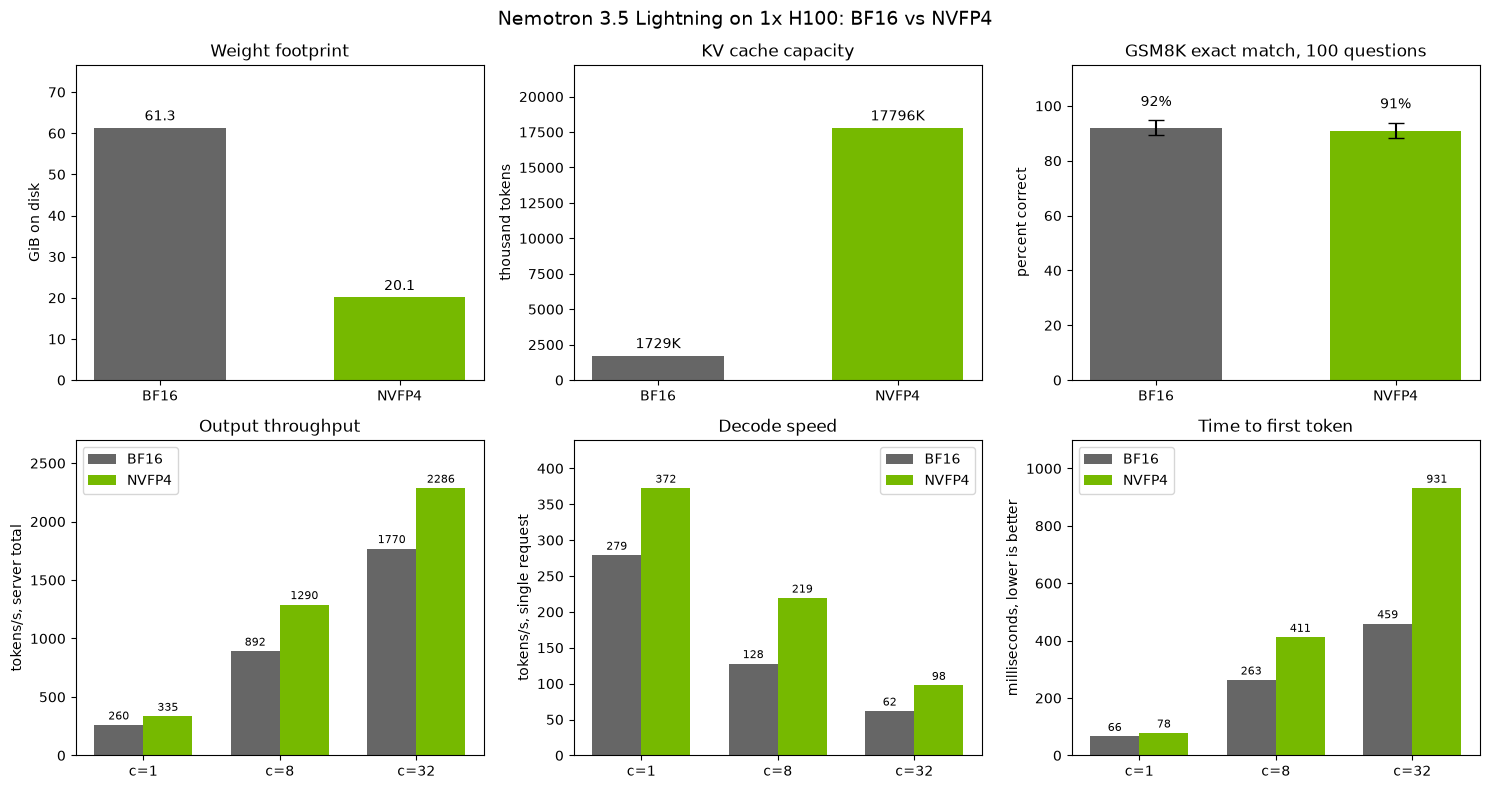

In [13]:
import matplotlib.pyplot as plt

BF16_COLOR, NVFP4_COLOR = "#666666", "#76B900"
concurrencies = [l["concurrency"] for l in bf16["throughput"]]
labels = ["BF16", "NVFP4"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Nemotron 3.5 Lightning on 1x H100: BF16 vs NVFP4", fontsize=14)


def paired_bars(ax, values, title, ylabel, fmt="{:.1f}"):
    bars = ax.bar(labels, values, color=[BF16_COLOR, NVFP4_COLOR], width=0.55)
    ax.bar_label(bars, fmt=fmt, padding=3)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(max(values) * 1.25, 1))


def grouped_bars(ax, key, title, ylabel):
    width = 0.36
    positions = range(len(concurrencies))
    for offset, record, color, label in [
        (-width / 2, bf16, BF16_COLOR, "BF16"),
        (width / 2, nvfp4, NVFP4_COLOR, "NVFP4"),
    ]:
        bars = ax.bar([p + offset for p in positions],
                      [l[key] for l in record["throughput"]],
                      width, color=color, label=label)
        ax.bar_label(bars, fmt="{:.0f}", padding=2, fontsize=8)
    ax.set_xticks(list(positions), [f"c={c}" for c in concurrencies])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.margins(y=0.18)  # room for the bar labels and the legend
    ax.legend()


paired_bars(axes[0][0],
            [bf16["weights_bytes"] / 2**30, nvfp4["weights_bytes"] / 2**30],
            "Weight footprint", "GiB on disk")
if bf16["kv_cache_tokens"] and nvfp4["kv_cache_tokens"]:
    paired_bars(axes[0][1],
                [bf16["kv_cache_tokens"] / 1000, nvfp4["kv_cache_tokens"] / 1000],
                "KV cache capacity", "thousand tokens", fmt="{:.0f}K")
else:
    axes[0][1].set_axis_off()
    axes[0][1].text(0.5, 0.5, "KV cache capacity not reported.\nRead 'GPU KV cache size'\n"
                    "from each server log.", ha="center", va="center")

accuracies = [bf16["accuracy"]["accuracy"] * 100, nvfp4["accuracy"]["accuracy"] * 100]
errors = [bf16["accuracy"]["stderr"] * 100, nvfp4["accuracy"]["stderr"] * 100]
bars = axes[0][2].bar(labels, accuracies, yerr=errors, capsize=6,
                      color=[BF16_COLOR, NVFP4_COLOR], width=0.55)
axes[0][2].bar_label(bars, fmt="{:.0f}%", padding=8)
axes[0][2].set_title(f"GSM8K exact match, {bf16['accuracy']['questions']} questions")
axes[0][2].set_ylabel("percent correct")
axes[0][2].set_ylim(0, 115)

grouped_bars(axes[1][0], "output_throughput_tok_s", "Output throughput", "tokens/s, server total")
grouped_bars(axes[1][1], "decode_tok_s_median", "Decode speed", "tokens/s, single request")
grouped_bars(axes[1][2], "ttft_ms_median", "Time to first token", "milliseconds, lower is better")

fig.tight_layout()
plt.show()

### Same question, both formats

The numbers say the answers survived. This is what that looks like on one problem, generated greedily in both runs so any difference is the format rather than the sampler.

In [14]:
for record in (bf16, nvfp4):
    print(f"===== {record['label'].upper()} =====")
    print(record["sample"]["content"])
    print()

===== BF16 =====
The express train catches up **240 km** from the station. Here's the step-by-step reasoning:

1. **Head start distance:** The freight train travels for 2 hours before the express train departs, covering a distance of \( 40 \text{ km/h} \times 2 \text{ h} = 80 \text{ km} \).

2. **Relative speed:** Since both trains move in the same direction, the express train closes the gap at a rate of \( 60 \text{ km/h} - 40 \text{ km/h} = 20 \text{ km/h} \).

3. **Time to catch up:** To close the 80 km gap at 20 km/h takes \( 80 \div 20 = 4 \) hours of travel for the express train.

4. **Distance from station:** In those 4 hours, the express train travels \( 60 \text{ km/h} \times 4 \text{ h} = 240 \text{ km} \). (You can verify: the freight train travels \( 40 \text{ km/h} \times 6 \text{ h} = 240 \text{ km} \) total, confirming they meet at the same point.)

**Answer:** The express train catches up **240 km** from the station.

===== NVFP4 =====
Here's the step-by-step reasoning:

## Cleanup and next steps

To free resources after this notebook:

1. Stop the Docker container in the terminal where it was started (`Ctrl+C`). The `--rm` flag removes it on exit.
2. Restart the kernel if needed to ensure a clean state.
3. Both runs stay in `results/` as JSON. The checkpoints stay in `~/.cache/huggingface` and take about 88 GB together.

Where to go from here:

- **Change one variable and rerun.** `CONCURRENCIES`, `OUTPUT_TOKENS`, and `ACCURACY_QUESTIONS` sit at the top of the harness. Pushing concurrency past 32 widens the gap.
- **Add speculative decoding.** Serve NVFP4 with a DSpark or DFlash draft model from the [Nemotron 3.5 Lightning cookbooks](https://github.com/NVIDIA-NeMo/Nemotron/tree/main/usage-cookbook/Nemotron-3.5-Lightning), then rerun the harness to see what the freed memory buys on top of the format.
- **Run it on Blackwell.** A GB200 or B200 gives both formats far more headroom. Note that this checkpoint quantizes weights only, so putting FP4 through the Blackwell tensor cores needs a checkpoint that quantizes activations as well.